#📌 Extracción

In [168]:
import pandas as pd

In [169]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [170]:
datos_api = pd.read_json(url)
datos = datos_api.copy()
datos.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [171]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [172]:
#@title Ejemplo del Json

ejemplo_json=("""
 {
    "customerID": "0002-ORFBO",
    "Churn": "No",
    "customer": {
      "gender": "Female",
      "SeniorCitizen": 0,
      "Partner": "Yes",
      "Dependents": "Yes",
      "tenure": 9
    },
    "phone": {
      "PhoneService": "Yes",
      "MultipleLines": "No"
    },
    "internet": {
      "InternetService": "DSL",
      "OnlineSecurity": "No",
      "OnlineBackup": "Yes",
      "DeviceProtection": "No",
      "TechSupport": "Yes",
      "StreamingTV": "Yes",
      "StreamingMovies": "No"
    },
    "account": {
      "Contract": "One year",
      "PaperlessBilling": "Yes",
      "PaymentMethod": "Mailed check",
      "Charges": {
        "Monthly": 65.6,
        "Total": "593.3"
      }
    }
  },""")

In [173]:
datos.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

#🔧 Transformación

In [174]:
#@title  Normalizar datos
customer=pd.json_normalize(datos_api.customer)
phone = pd.json_normalize(datos_api.phone)
internet = pd.json_normalize(datos_api.internet)
account = pd.json_normalize(datos_api.account)

datos = pd.concat([datos_api.customerID, datos_api.Churn, customer, phone, internet, account], axis=1)

In [175]:
datos = datos.rename(columns={'Charges.Monthly': 'Charges_Monthly',
                              'Charges.Total': 'Charges_Total'})
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [176]:
datos.replace("Yes", True, inplace=True)
datos.replace("No", False, inplace=True)
datos.sample()

/tmp/ipykernel_1760/2189884381.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos.replace("No", False, inplace=True)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
2008,2834-SPCJV,True,Male,0,True,False,52,True,False,Fiber optic,True,False,False,False,True,False,Month-to-month,False,Electronic check,84.1,4348.65


In [177]:
import numpy as np
#datos['Charges_Total'] = pd.to_numeric(datos['Charges_Total'])
#Al tratrar de cambiar la columna Chagers_Total a float quedan 11 columnas como nulo.
#Esto ocurre cuando tenure es igual a cero se deja esta columna vacía
#posiblemente nuevos clientes
datos[datos.tenure == 0]


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
975,1371-DWPAZ,False,Female,0,True,True,0,False,No phone service,DSL,True,True,True,True,True,False,Two year,False,Credit card (automatic),56.05,
1775,2520-SGTTA,False,Female,0,True,True,0,True,False,False,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.00,
1955,2775-SEFEE,False,Male,0,False,True,0,True,True,DSL,True,True,False,True,False,False,Two year,True,Bank transfer (automatic),61.90,
2075,2923-ARZLG,False,Male,0,True,True,0,True,False,False,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,True,Mailed check,19.70,
2232,3115-CZMZD,False,Male,0,False,True,0,True,False,False,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.25,
2308,3213-VVOLG,False,Male,0,True,True,0,True,True,False,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.35,
2930,4075-WKNIU,False,Female,0,True,True,0,True,True,DSL,False,True,True,True,True,False,Two year,False,Mailed check,73.35,
3134,4367-NUYAO,False,Male,0,True,True,0,True,True,False,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.75,
3203,4472-LVYGI,False,Female,0,True,True,0,False,No phone service,DSL,True,False,True,True,True,False,Two year,True,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,False,Female,0,True,True,0,True,False,DSL,True,True,True,False,True,True,Two year,False,Mailed check,80.85,


In [178]:
# Primero convertimos a numérico (esto convierte los espacios en NaN)
datos['Charges_Total'] = pd.to_numeric(datos['Charges_Total'], errors='coerce')

# Luego rellenamos los NaN con 0.0
datos['Charges_Total'] = datos['Charges_Total'].fillna(0.0)

# Verificamos que ya no existan nulos y veamos los valores
print(f"Nulos en Charges_Total: {datos['Charges_Total'].isnull().sum()}")
display(datos[datos.tenure == 0][['customerID', 'tenure', 'Charges_Total']])

Nulos en Charges_Total: 0


,customerID,tenure,Charges_Total
975,1371-DWPAZ,0,0.0
1775,2520-SGTTA,0,0.0
1955,2775-SEFEE,0,0.0
2075,2923-ARZLG,0,0.0
2232,3115-CZMZD,0,0.0
2308,3213-VVOLG,0,0.0
2930,4075-WKNIU,0,0.0
3134,4367-NUYAO,0,0.0
3203,4472-LVYGI,0,0.0
4169,5709-LVOEQ,0,0.0


In [179]:
datos['Charges_Total'] = pd.to_numeric(datos['Charges_Total'], errors='coerce').fillna(0.0)
datos['Charges_Total'].dtype

dtype('float64')

In [180]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   bool   
 5   Dependents        7267 non-null   bool   
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   bool   
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [190]:
# Verificamos los valores únicos de cada columna para entender mejor las categorías
def datos_unicos():
  for col in datos.columns:
      print(f"--- Columna: {col} ---")
      print(datos[col].unique())
      print("\n")

datos_unicos()


--- Columna: customerID ---
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']


--- Columna: Churn ---
[False True]


--- Columna: gender ---
['Female' 'Male']


--- Columna: SeniorCitizen ---
[0 1]


--- Columna: Partner ---
[ True False]


--- Columna: Dependents ---
[ True False]


--- Columna: tenure ---
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]


--- Columna: PhoneService ---
[ True False]


--- Columna: MultipleLines ---
[False  True]


--- Columna: InternetService ---
['DSL' 'Fiber optic' False]


--- Columna: OnlineSecurity ---
[False  True]


--- Columna: OnlineBackup ---
[ True False]


--- Columna: DeviceProtection ---
[False  True]


--- Columna: TechSupport ---
[ True False]


--- Columna: StreamingTV ---
[ True False]


--- Columna: StreamingMovies ---
[False

In [188]:
# Optamos por el comportamiento futuro para evitar el FutureWarning
pd.set_option('future.no_silent_downcasting', True)

columnas_servicio = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in columnas_servicio:
    datos[col] = datos[col].replace(['No internet service', 'No phone service'], False)

display(datos[columnas_servicio].sample(5))

,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
3560,False,False,True,True,False,False,True
1407,True,False,True,True,True,True,True
7066,False,False,True,True,False,True,True
1798,True,False,False,False,False,False,False
6147,False,True,True,True,False,False,False


In [182]:
#vamos a revisar la cantidad de registro con churn vacio
cantidad_vacios = (datos['Churn'] == '').sum()
datos[datos['Churn'] == ''].head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
30,0047-ZHDTW,,Female,0,False,False,11,True,True,Fiber optic,True,False,False,False,False,False,Month-to-month,True,Bank transfer (automatic),79.00,929.30
75,0120-YZLQA,,Male,0,False,False,71,True,False,False,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,True,Credit card (automatic),19.90,1355.10
96,0154-QYHJU,,Male,0,False,False,29,True,False,DSL,True,True,False,True,False,False,One year,True,Electronic check,58.75,1696.20
98,0162-RZGMZ,,Female,1,False,False,5,True,False,DSL,True,True,False,True,False,False,Month-to-month,False,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,Male,1,True,False,65,True,True,Fiber optic,False,True,True,False,True,True,One year,True,Bank transfer (automatic),103.15,6792.45


In [183]:
datos.shape

(7267, 21)

In [184]:
peso_registros_sin_churn =(100* (datos['Churn'] == '').sum()/datos.shape[0])
peso_registros_sin_churn #3.08%

np.float64(3.0824274115866244)

In [185]:

datos_sin_churn = datos[datos['Churn'] == ''].copy()
datos = datos[datos['Churn'] != ''].copy()

print(f"Registros en DataFrame principal: {datos.shape[0]}")
print(f"Registros guardados por separado: {datos_sin_churn.shape[0]}")

Registros en DataFrame principal: 7043
Registros guardados por separado: 224


In [191]:
datos_unicos()


--- Columna: customerID ---
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']


--- Columna: Churn ---
[False True]


--- Columna: gender ---
['Female' 'Male']


--- Columna: SeniorCitizen ---
[0 1]


--- Columna: Partner ---
[ True False]


--- Columna: Dependents ---
[ True False]


--- Columna: tenure ---
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]


--- Columna: PhoneService ---
[ True False]


--- Columna: MultipleLines ---
[False  True]


--- Columna: InternetService ---
['DSL' 'Fiber optic' False]


--- Columna: OnlineSecurity ---
[False  True]


--- Columna: OnlineBackup ---
[ True False]


--- Columna: DeviceProtection ---
[False  True]


--- Columna: TechSupport ---
[ True False]


--- Columna: StreamingTV ---
[ True False]


--- Columna: StreamingMovies ---
[False

In [192]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   bool   
 5   Dependents        7043 non-null   bool   
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   bool   
 8   MultipleLines     7043 non-null   bool   
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   bool   
 11  OnlineBackup      7043 non-null   bool   
 12  DeviceProtection  7043 non-null   bool   
 13  TechSupport       7043 non-null   bool   
 14  StreamingTV       7043 non-null   bool   
 15  StreamingMovies   7043 non-null   bool   
 16  Contract          7043 non-null   object 
 17  

In [193]:
datos.sample()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
2162,3023-GFLBR,True,Female,0,True,True,33,True,True,Fiber optic,False,False,False,False,False,True,Month-to-month,False,Credit card (automatic),86.15,2745.7


np.int64(3402)

#DataFrame y formulas auxiliares

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo global de las gráficas
sns.set_theme(style="whitegrid")
pd.set_option('future.no_silent_downcasting', True)

# Función auxiliar para verificar valores únicos
def datos_unicos(df=datos):
    for col in df.columns:
        print(f"--- Columna: {col} ---")
        print(df[col].unique())
        print("\n")

In [211]:
# Resumen de categorías para referencia rápida
print(f"Total de clientes en el dataset: {len(datos)}")

print("\n--- Tipos de Contrato ---")
print(datos['Contract'].unique())

print("\n--- Métodos de Pago ---")
print(datos['PaymentMethod'].unique())

print("\n--- Tipos de Internet ---")
print(datos['InternetService'].unique())

print("\n--- Servicios Adicionales Analizados ---")
print(columnas_servicio)

Total de clientes en el dataset: 7043

--- Tipos de Contrato ---
['One year' 'Month-to-month' 'Two year']

--- Métodos de Pago ---
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

--- Tipos de Internet ---
['DSL' 'Fiber optic' False]

--- Servicios Adicionales Analizados ---
['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


In [212]:
# Definimos las columnas que queremos conservar y las que vamos a agrupar
columnas_base = ['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Contract', 'PaymentMethod', 'Charges_Monthly', 'Charges_Total']

# Creamos el DataFrame simplificado
datos_resumen = datos[columnas_base].copy()

# Asignamos la cantidad total de servicios (usando la lógica que incluye Internet)
datos_resumen['Cantidad_Servicios'] = datos['Total_Services']

# Mostramos el resultado
display(datos_resumen.head())
print(f"\nDimensiones del nuevo DataFrame: {datos_resumen.shape}")

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaymentMethod,Charges_Monthly,Charges_Total,Cantidad_Servicios
0,0002-ORFBO,False,Female,0,True,True,9,One year,Mailed check,65.6,593.30,5
1,0003-MKNFE,False,Male,0,False,False,9,Month-to-month,Mailed check,59.9,542.40,4
2,0004-TLHLJ,True,Male,0,False,False,4,Month-to-month,Electronic check,73.9,280.85,3
3,0011-IGKFF,True,Male,1,True,False,13,Month-to-month,Electronic check,98.0,1237.85,6
4,0013-EXCHZ,True,Female,1,True,False,3,Month-to-month,Mailed check,83.9,267.40,4



Dimensiones del nuevo DataFrame: (7043, 12)


In [213]:
datos_resumen[datos_resumen.Cantidad_Servicios==0]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaymentMethod,Charges_Monthly,Charges_Total,Cantidad_Servicios


#📊 Carga y análisis

In [186]:
# Análisis descriptivo de las variables numéricas
estadisticas_descriptivas = datos.describe()

# Añadimos la mediana manualmente ya que no siempre se incluye en describe()
medianas = datos.select_dtypes(include=[np.number]).median()
estadisticas_descriptivas.loc['median'] = medianas

display(estadisticas_descriptivas)

,SeniorCitizen,tenure,Charges_Monthly,Charges_Total
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000
median,0.000000,29.000000,70.350000,1394.550000


##Recuento de evasión por variables categóricas

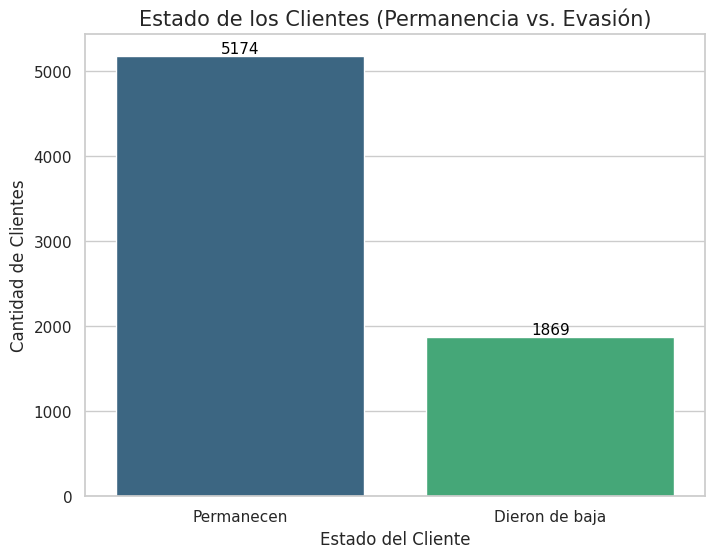

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# Creamos el gráfico de recuento
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Churn', data=datos, hue='Churn', palette='viridis', legend=False)

# Personalizamos las etiquetas del eje X
ax.set_xticks([0, 1])
ax.set_xticklabels(['Permanecen', 'Dieron de baja'])

# Añadimos títulos y etiquetas
plt.title('Estado de los Clientes (Permanencia vs. Evasión)', fontsize=15)
plt.xlabel('Estado del Cliente', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Añadimos el número exacto sobre cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

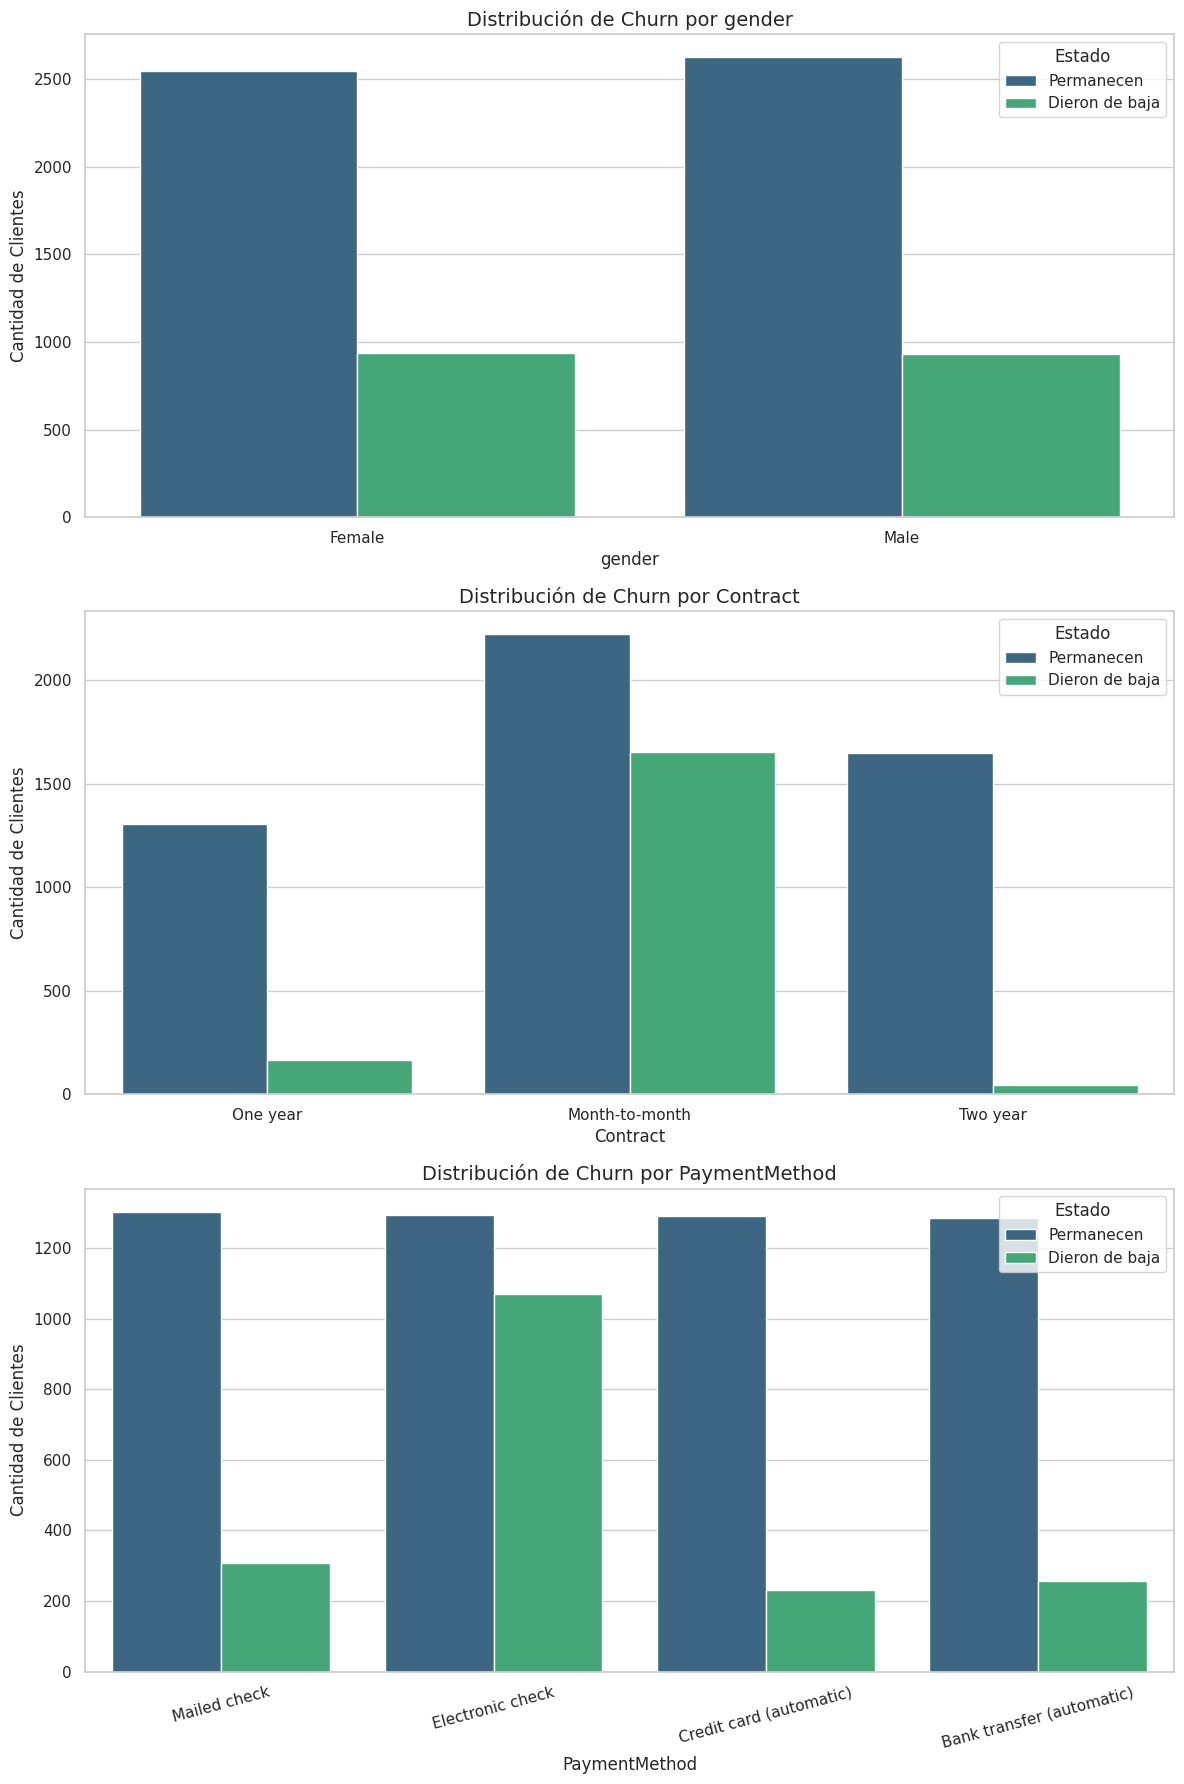

In [197]:
#@title Recuento de evasión por variables categóricas

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Lista de variables categóricas a analizar
vars_cat = ['gender', 'Contract', 'PaymentMethod']

# Creamos la figura con subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18))

for i, col in enumerate(vars_cat):
    # Creamos el gráfico de barras comparativo
    sns.countplot(x=col, hue='Churn', data=datos, palette='viridis', ax=axes[i])

    # Personalización
    axes[i].set_title(f'Distribución de Churn por {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Cantidad de Clientes', fontsize=12)
    axes[i].legend(title='Estado', labels=['Permanecen', 'Dieron de baja'])

    # Rotar etiquetas si es necesario (especialmente para PaymentMethod)
    if col == 'PaymentMethod':
        axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

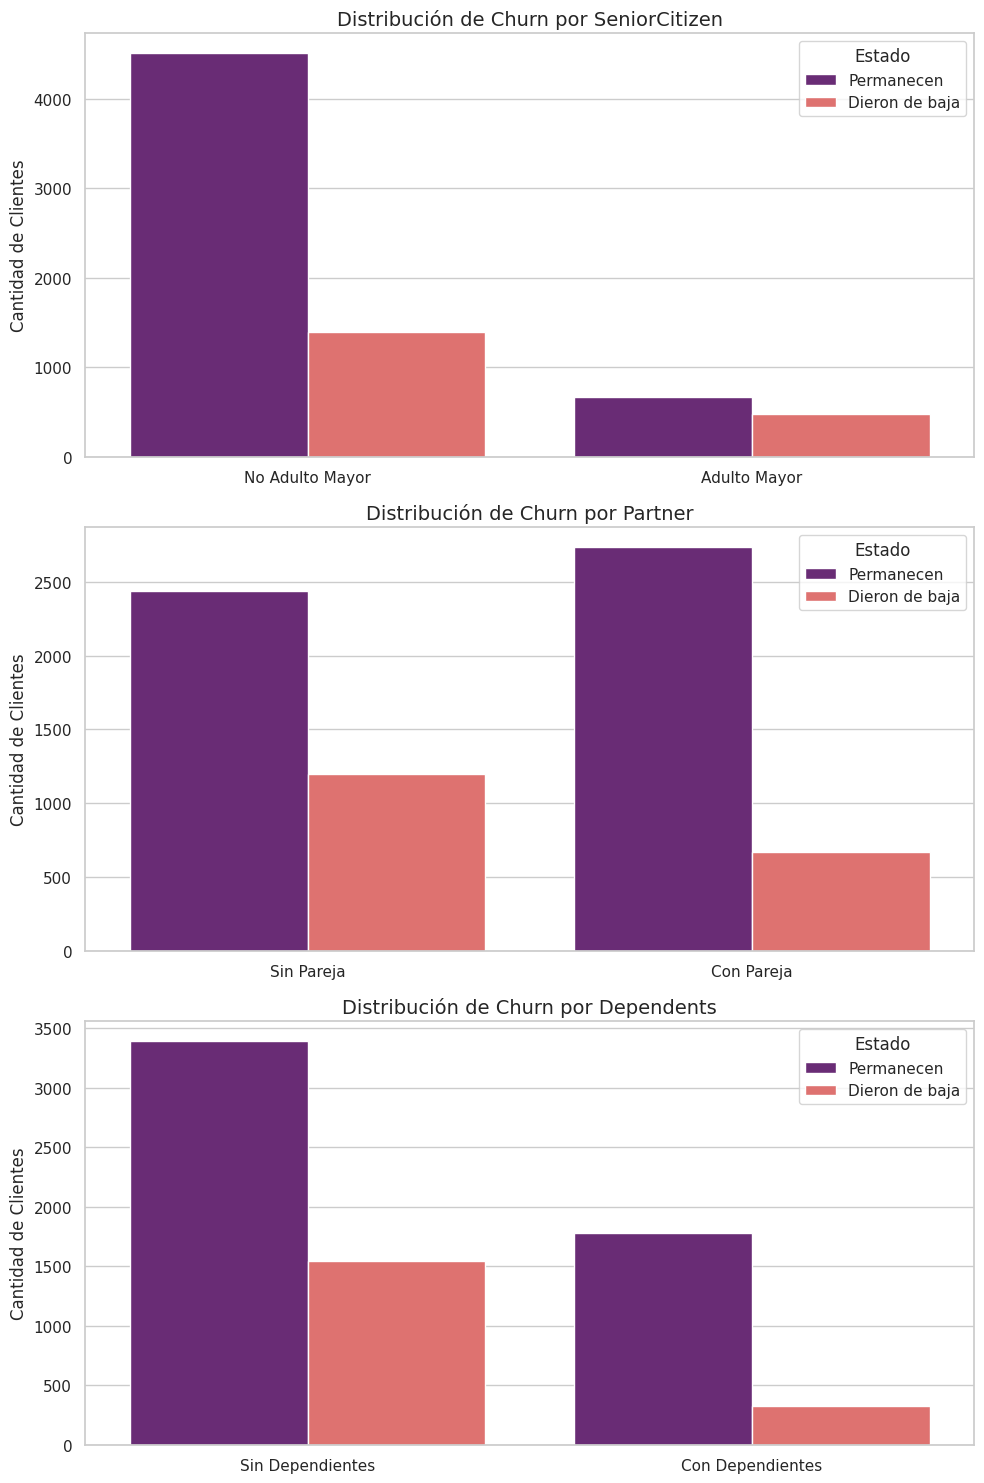

In [199]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Lista de variables demográficas adicionales
vars_demo = ['SeniorCitizen', 'Partner', 'Dependents']
etiquetas_personalizadas = {
    'SeniorCitizen': ['No Adulto Mayor', 'Adulto Mayor'],
    'Partner': ['Sin Pareja', 'Con Pareja'],
    'Dependents': ['Sin Dependientes', 'Con Dependientes']
}

# Creamos la figura con subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))

for i, col in enumerate(vars_demo):
    # Creamos el gráfico de barras comparativo
    sns.countplot(x=col, hue='Churn', data=datos, palette='magma', ax=axes[i])

    # Personalización de títulos y leyenda
    axes[i].set_title(f'Distribución de Churn por {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de Clientes', fontsize=12)
    axes[i].legend(title='Estado', labels=['Permanecen', 'Dieron de baja'])

    # Aplicamos las etiquetas significativas en el eje X
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(etiquetas_personalizadas[col])

plt.tight_layout()
plt.show()

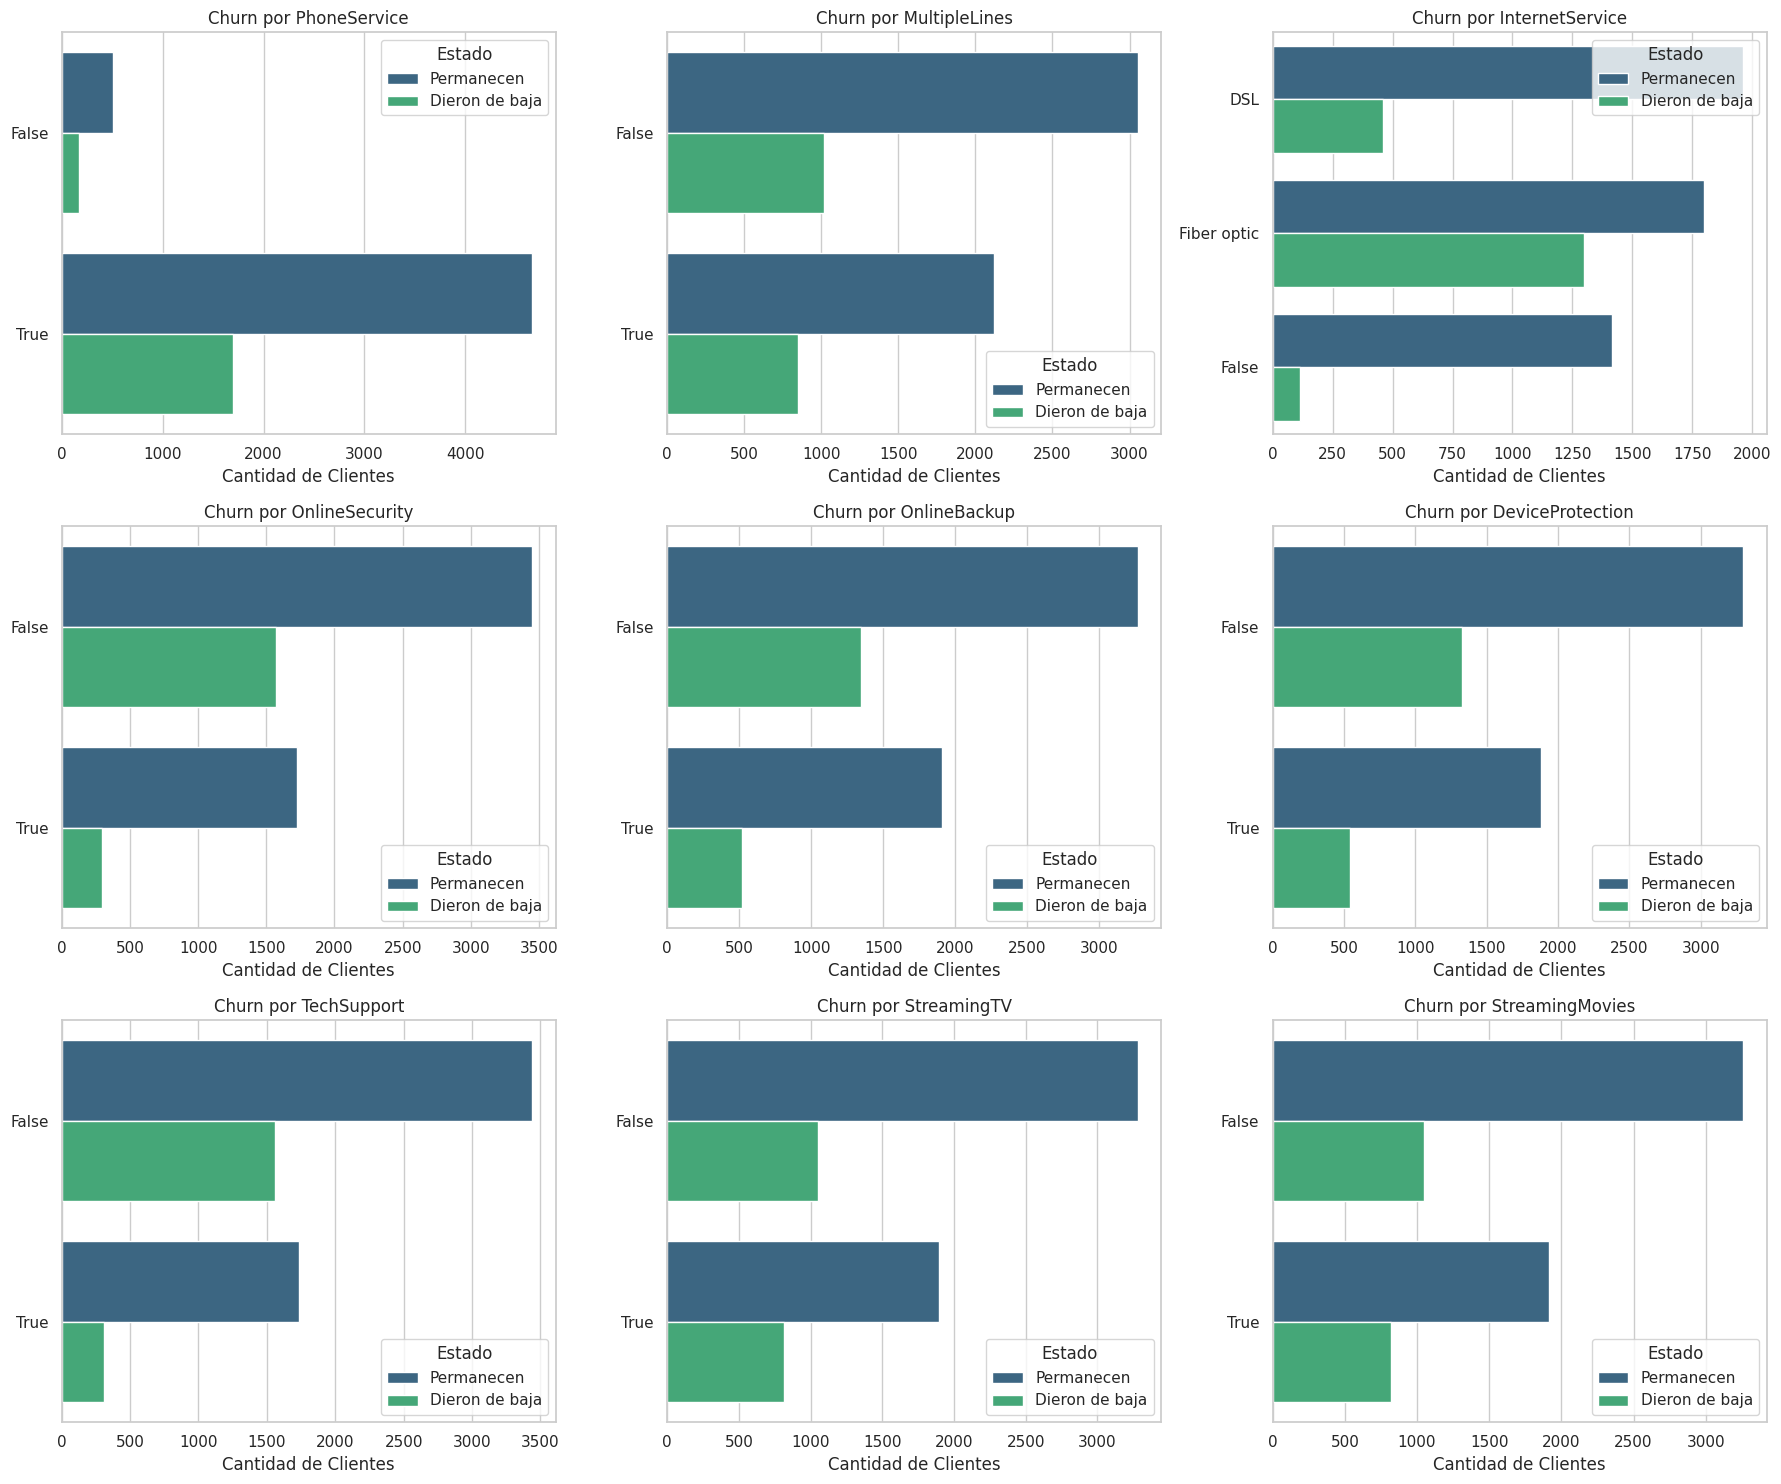

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de columnas de servicios para analizar
columnas_servicios = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                      'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Configuramos la cuadrícula de gráficos (3 filas x 3 columnas)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(columnas_servicios):
    # Usamos 'y' en lugar de 'x' para hacer las barras horizontales
    sns.countplot(y=col, hue='Churn', data=datos, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Churn por {col}', fontsize=12)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('Cantidad de Clientes')

    # Etiquetas personalizadas para la leyenda
    axes[i].legend(title='Estado', labels=['Permanecen', 'Dieron de baja'])

plt.tight_layout()
plt.show()

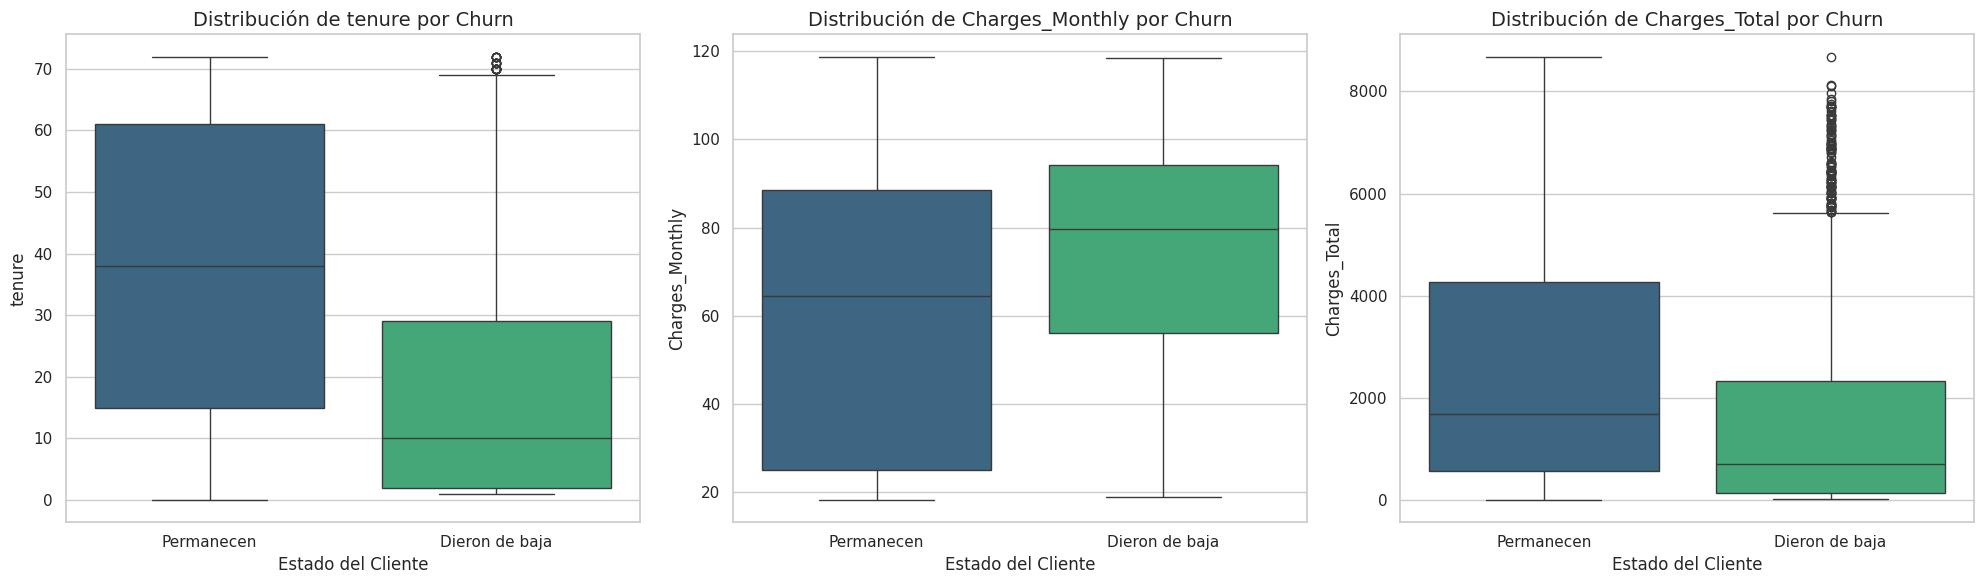

Promedios por grupo (Churn):


,tenure,Charges_Monthly,Charges_Total
Churn,,,
False,37.569965,61.265124,2549.911442
True,17.979133,74.441332,1531.796094


In [203]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Lista de variables numéricas relevantes
vars_num = ['tenure', 'Charges_Monthly', 'Charges_Total']

# Creamos la figura con subplots (1 fila, 3 columnas)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(vars_num):
    # Creamos un boxplot
    sns.boxplot(x='Churn', y=col, data=datos, palette='viridis', ax=axes[i], hue='Churn', legend=False)

    # Personalización fijando primero los ticks para evitar el UserWarning
    axes[i].set_title(f'Distribución de {col} por Churn', fontsize=14)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Permanecen', 'Dieron de baja'])
    axes[i].set_xlabel('Estado del Cliente')

plt.tight_layout()
plt.show()

# También calculamos las medias para tener datos precisos
print("Promedios por grupo (Churn):")
display(datos.groupby('Churn')[vars_num].mean())

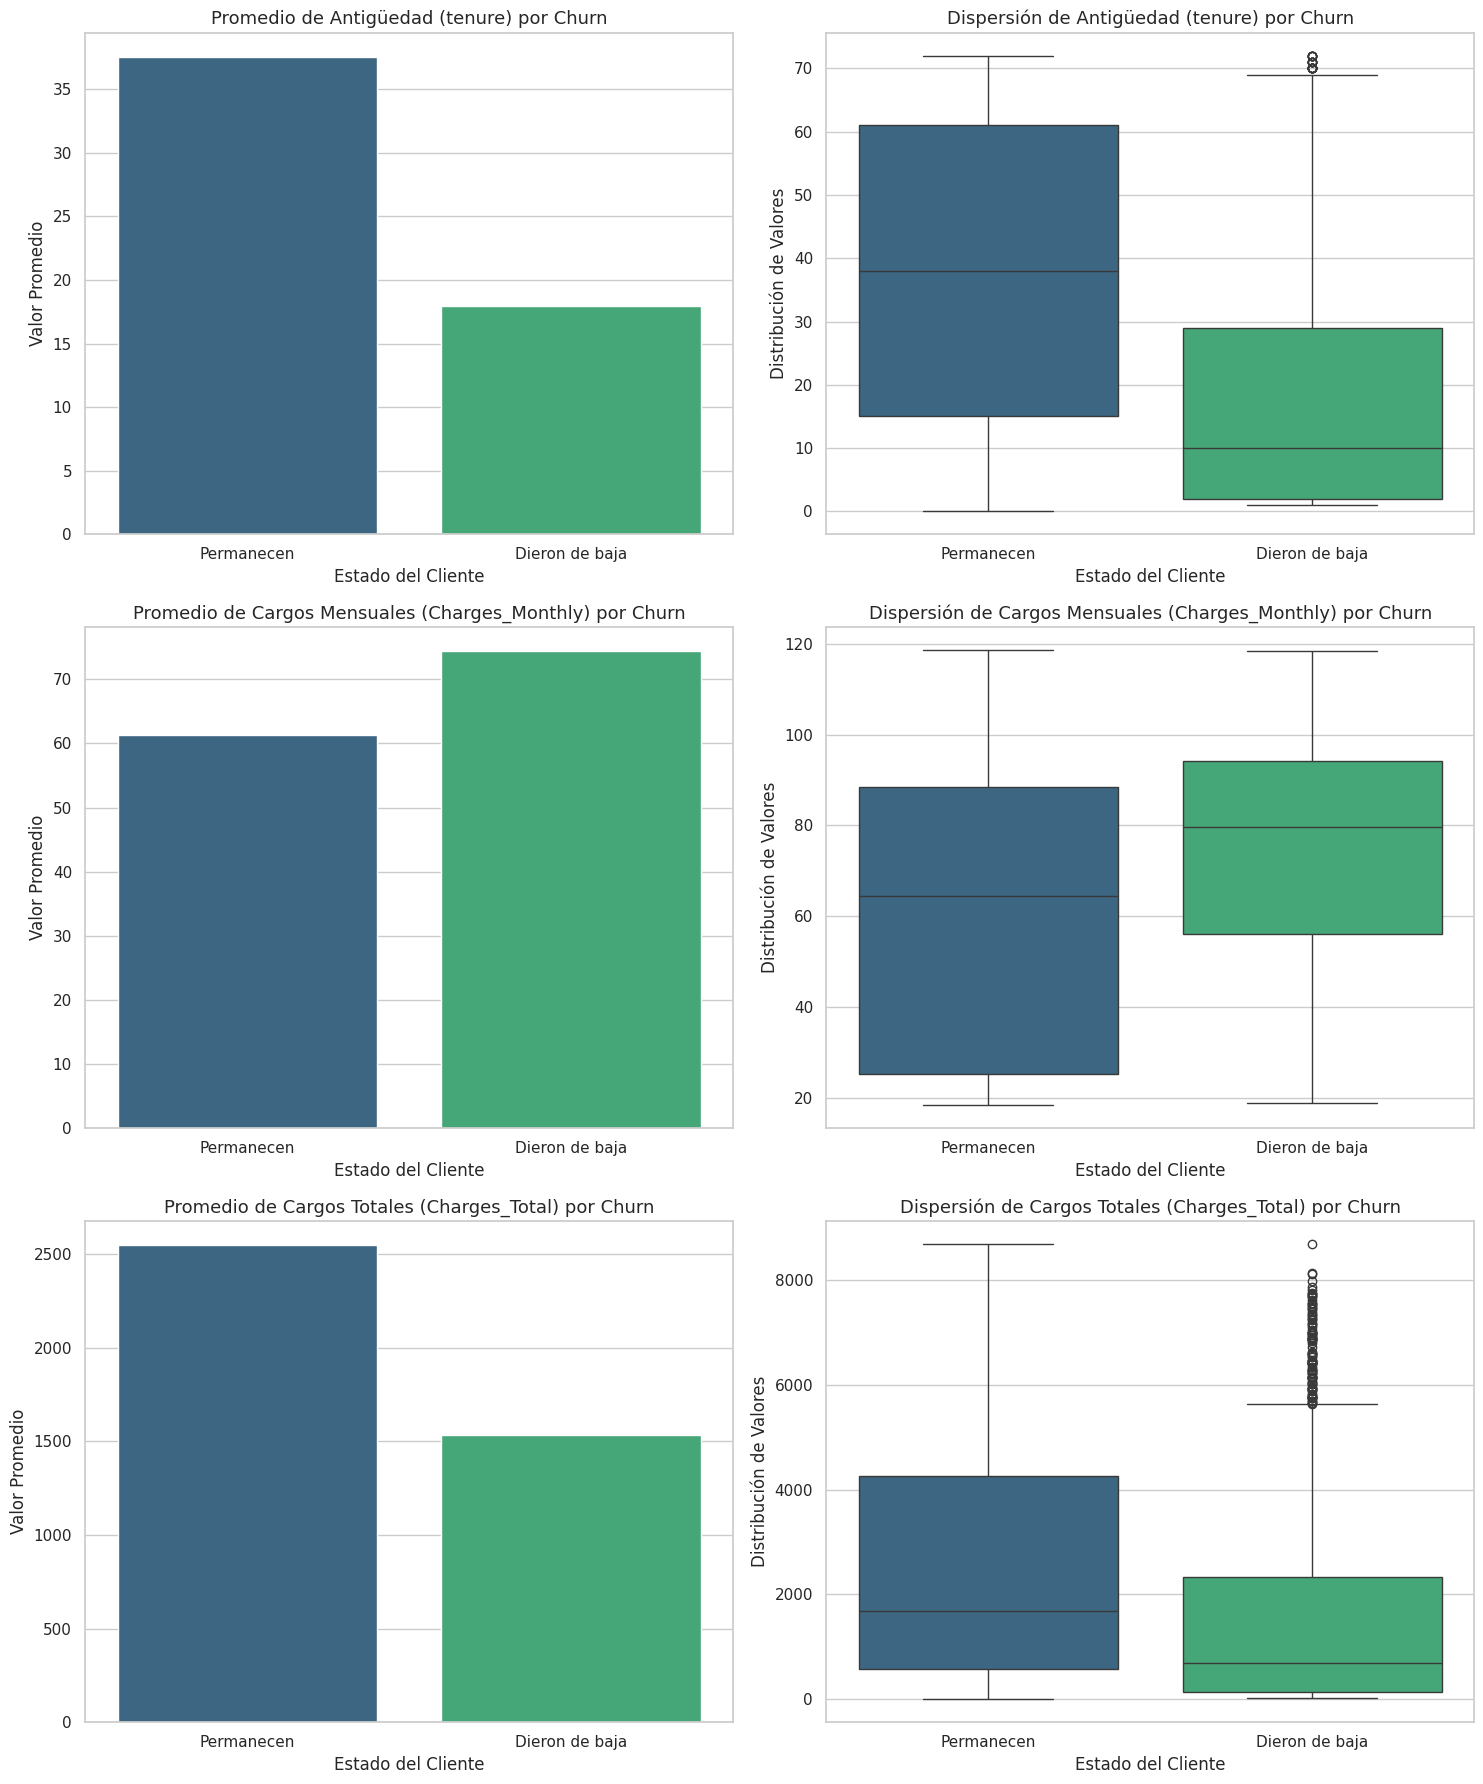

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Mapeo de nombres a etiquetas significativas en español
etiquetas_num = {
    'tenure': 'Antigüedad (tenure)',
    'Charges_Monthly': 'Cargos Mensuales (Charges_Monthly)',
    'Charges_Total': 'Cargos Totales (Charges_Total)'
}

vars_num = ['tenure', 'Charges_Monthly', 'Charges_Total']

# Creamos una figura con 3 filas y 2 columnas
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))

for i, col in enumerate(vars_num):
    nombre_esp = etiquetas_num[col]

    # 1. Gráfica de Barras (Promedio) a la izquierda
    sns.barplot(x='Churn', y=col, data=datos, palette='viridis', ax=axes[i, 0], hue='Churn', legend=False, errorbar=None)
    axes[i, 0].set_title(f'Promedio de {nombre_esp} por Churn', fontsize=13)
    axes[i, 0].set_xticks([0, 1])
    axes[i, 0].set_xticklabels(['Permanecen', 'Dieron de baja'])
    axes[i, 0].set_ylabel('Valor Promedio')
    axes[i, 0].set_xlabel('Estado del Cliente')

    # 2. Boxplot a la derecha
    sns.boxplot(x='Churn', y=col, data=datos, palette='viridis', ax=axes[i, 1], hue='Churn', legend=False)
    axes[i, 1].set_title(f'Dispersión de {nombre_esp} por Churn', fontsize=13)
    axes[i, 1].set_xticks([0, 1])
    axes[i, 1].set_xticklabels(['Permanecen', 'Dieron de baja'])
    axes[i, 1].set_ylabel('Distribución de Valores')
    axes[i, 1].set_xlabel('Estado del Cliente')

plt.tight_layout()
plt.show()

##Observaciones
* Se observo que los quientes mas propensos a abandonar el servicio son aquellos que tienen un contrato de renta mensual y los que realizan los pagos con cheques electronicos.

#📄Informe final

# 📄 Informe Final: Análisis de Evasión de Clientes (Churn)

## 🔹 1. Introducción
El objetivo de este análisis es identificar los factores críticos que influyen en la **evasión de clientes (Churn)** de TelecomX. El Churn representa la pérdida de suscriptores, un problema vital para la rentabilidad, ya que retener a un cliente existente es considerablemente más económico que adquirir uno nuevo.

## 🔹 2. Limpieza y Tratamiento de Datos
El proceso de preparación de datos incluyó los siguientes hitos técnicos:
*   **Extracción y Normalización:** Se procesó un archivo JSON con estructuras anidadas (`customer`, `phone`, `internet`, `account`), convirtiéndolo en un DataFrame plano y manejable.
*   **Conversión de Tipos:** Transformamos columnas clave como `Charges_Total` a formato numérico y las variables categóricas 'Yes'/'No' a booleanos (`True`/`False`).
*   **Tratamiento de Nulos:** Identificamos que los valores faltantes en cargos totales correspondían a nuevos clientes (`tenure = 0`), por lo que se imputaron con `0.0`.
*   **Filtrado de Calidad:** Se separaron 224 registros (aprox. 3%) que no tenían etiqueta de Churn para no sesgar el análisis.

## 🔹 3. Análisis Exploratorio de Datos (EDA)
A través de las visualizaciones, identificamos patrones determinantes:
*   **Variables Categóricas:** Los clientes con contratos **mes a mes** y que pagan con **cheque electrónico** tienen la mayor tasa de abandono.
*   **Demografía:** Los **adultos mayores** y personas **sin dependientes o pareja** muestran una mayor vulnerabilidad a la evasión.
*   **Servicios:** El servicio de **fibra óptica** presenta más bajas que el DSL, mientras que servicios de valor agregado como **Soporte Técnico** y **Seguridad Online** actúan como anclas de retención.
*   **Variables Numéricas:** Existe una correlación clara: a **mayores cargos mensuales** y **menor antigüedad**, mayor es el riesgo de fuga.

## 🔹 4. Conclusiones e Insights
*   El perfil de alto riesgo es un cliente nuevo, con contrato mensual, factura elevada y sin servicios de soporte adicionales.
*   La antigüedad es el mejor protector: una vez que el cliente supera los 20 meses, la probabilidad de abandono disminuye drásticamente.

## 🔹 5. Recomendaciones Estratégicas
1.  **Incentivos de Permanencia:** Crear campañas para migrar a clientes de contratos mensuales a anuales mediante descuentos.
2.  **Fidelización Temprana:** Implementar un programa de 'Onboarding' para nuevos clientes durante los primeros 6 meses.
3.  **Venta Cruzada (Cross-selling):** Promocionar servicios de seguridad y soporte técnico, ya que aumentan la lealtad del cliente.
4.  **Revisión de Tarifas:** Analizar la competitividad de los precios para clientes con cargos mensuales superiores a $70, donde se concentra la mayor fuga.

#Extra

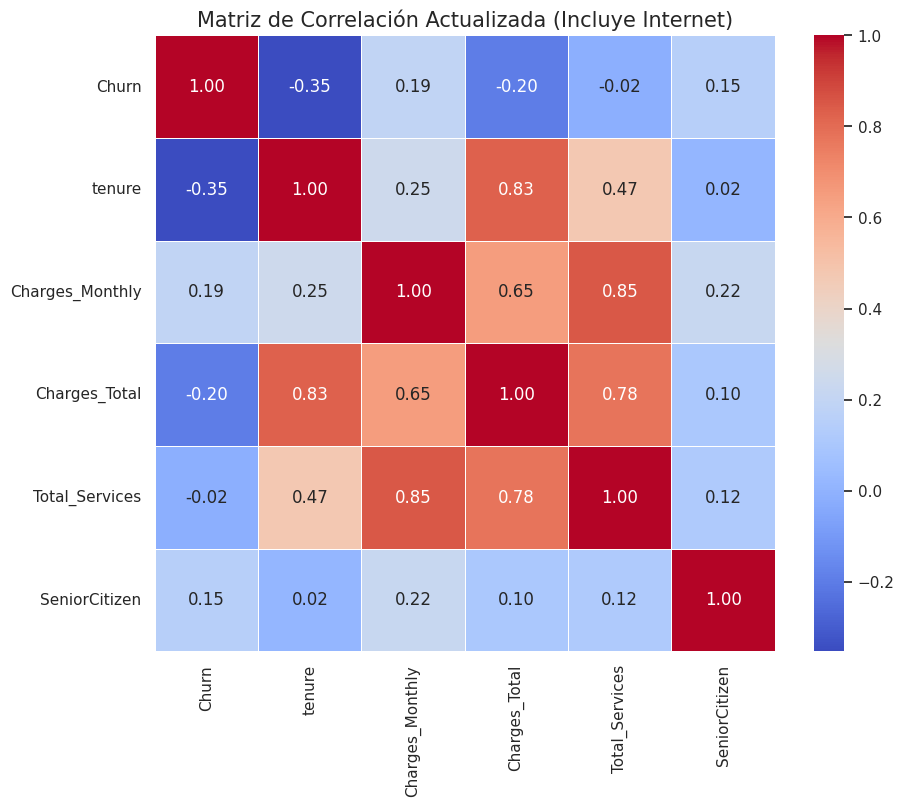

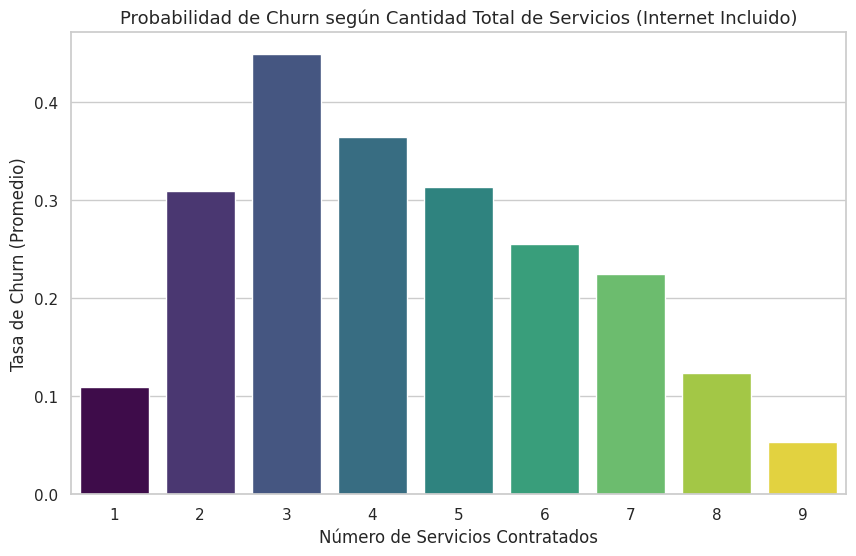

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Ajustamos la lista de servicios incluyendo la conexión a internet
# Contamos los servicios booleanos (True/False)
servicios_booleanos = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                      'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Calculamos el total: servicios booleanos + 1 si tiene InternetService (DSL o Fiber optic)
datos['Total_Services'] = datos[servicios_booleanos].sum(axis=1) + (datos['InternetService'] != False).astype(int)

# 2. Preparamos datos para correlación
columnas_corr = ['Churn', 'tenure', 'Charges_Monthly', 'Charges_Total', 'Total_Services', 'SeniorCitizen']
df_corr = datos[columnas_corr].copy()
df_corr['Churn'] = df_corr['Churn'].astype(int)

# 3. Visualización Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación Actualizada (Incluye Internet)', fontsize=15)
plt.show()

# 4. Nueva relación: Cantidad de servicios vs Churn
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Services', y='Churn', data=df_corr, hue='Total_Services', palette='viridis', errorbar=None, legend=False)
plt.title('Probabilidad de Churn según Cantidad Total de Servicios (Internet Incluido)', fontsize=13)
plt.ylabel('Tasa de Churn (Promedio)')
plt.xlabel('Número de Servicios Contratados')
plt.show()

In [208]:
# Filtramos los clientes que no tienen ningún servicio adicional contratado
clientes_cero_servicios = datos[datos['Total_Services'] == 0]

print(f"Cantidad de clientes con 0 servicios: {len(clientes_cero_servicios)}")
display(clientes_cero_servicios[['customerID', 'tenure', 'Charges_Monthly', 'InternetService', 'PhoneService']].head(10))

Cantidad de clientes con 0 servicios: 80


,customerID,tenure,Charges_Monthly,InternetService,PhoneService
19,0023-HGHWL,1,25.10,DSL,False
289,0420-BWTPW,8,25.50,DSL,False
425,0612-RTZZA,1,25.25,DSL,False
427,0616-ATFGB,1,25.05,DSL,False
466,0661-XEYAN,1,25.80,DSL,False
529,0746-JTRFU,2,25.05,DSL,False
561,0804-XBFBV,11,25.20,DSL,False
713,1024-GUALD,1,24.80,DSL,False
942,1329-VHWNP,7,25.05,DSL,False
944,1334-FJSVR,1,24.25,DSL,False
